In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# display settings
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv(r"C:\Users\ADMIN\Desktop\loan-risk-analytics-project\UCI_Credit_Card.csv")

In [3]:
df.shape
df.columns.tolist()
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [4]:
# 1. Drop ID column
df = df.drop(columns=['ID'])

# 2. Rename target variable
df = df.rename(columns={'default.payment.next.month': 'default'})

# 3. Check duplicates
print("Duplicate rows:", df.duplicated().sum())

# 4. Final shape check
print("Shape after cleaning:", df.shape)

df.head()

Duplicate rows: 35
Shape after cleaning: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [5]:
df = df.drop_duplicates()

print("Duplicate rows after removal:", df.duplicated().sum())
print("New shape:", df.shape)

Duplicate rows after removal: 0
New shape: (29965, 24)


In [6]:
# List of repayment columns
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Average repayment delay
df['avg_pay_delay'] = df[pay_cols].mean(axis=1)

# Maximum delay (worst case)
df['max_pay_delay'] = df[pay_cols].max(axis=1)

# Quick check
df[['avg_pay_delay', 'max_pay_delay']].describe()

,avg_pay_delay,max_pay_delay
count,29965.000000,29965.000000
mean,-0.180978,0.439146
std,0.981368,1.344934
min,-2.000000,-2.000000
25%,-0.833333,0.000000
50%,0.000000,0.000000
75%,0.000000,2.000000
max,6.000000,8.000000


In [7]:
# Latest utilisation
df['utilisation_latest'] = df['BILL_AMT6'] / df['LIMIT_BAL']

# Average utilisation over last 6 months
bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
df['utilisation_avg'] = df[bill_cols].mean(axis=1) / df['LIMIT_BAL']

# Quick check
df[['utilisation_latest', 'utilisation_avg']].describe()

,utilisation_latest,utilisation_avg
count,29965.000000,29965.000000
mean,0.318954,0.373480
std,0.345333,0.351867
min,-1.509530,-0.232590
25%,0.007928,0.030300
50%,0.185875,0.285629
75%,0.582500,0.688454
max,3.885550,5.364308


In [8]:
# Latest payment ratio
df['pay_ratio_latest'] = df['PAY_AMT6'] / df['BILL_AMT6']

# Average payment ratio over 6 months
pay_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']
df['pay_ratio_avg'] = df[pay_cols].sum(axis=1) / df[bill_cols].sum(axis=1)

# Quick check
df[['pay_ratio_latest','pay_ratio_avg']].describe()

,pay_ratio_latest,pay_ratio_avg
count,2.668000e+04,2.920000e+04
mean,inf,inf
std,NaN,NaN
min,-1.134957e+04,-5.469286e+02
25%,3.307443e-02,4.222191e-02
50%,4.616485e-02,9.309175e-02
75%,3.173691e-01,6.233528e-01
max,inf,inf


In [9]:
# Clean latest payment ratio
df['pay_ratio_latest'] = df.apply(lambda row: 0 if row['BILL_AMT6'] <= 0 else row['PAY_AMT6']/row['BILL_AMT6'], axis=1)

# Clean average payment ratio over 6 months
df['pay_ratio_avg'] = df.apply(
    lambda row: 0 if row[bill_cols].sum() <= 0 else row[pay_cols].sum()/row[bill_cols].sum(),
    axis=1
)

# Cap extreme values (optional)
df['pay_ratio_latest'] = df['pay_ratio_latest'].clip(upper=2)
df['pay_ratio_avg'] = df['pay_ratio_avg'].clip(upper=2)

# Quick check
df[['pay_ratio_latest','pay_ratio_avg']].describe()

,pay_ratio_latest,pay_ratio_avg
count,29965.000000,29965.000000
mean,0.282280,0.345257
std,0.552826,0.451055
min,0.000000,0.000000
25%,0.000000,0.040995
50%,0.039551,0.085097
75%,0.146817,0.587641
max,2.000000,2.000000


In [10]:
# High utilisation (latest > 80%)
df['high_utilisation'] = (df['utilisation_latest'] > 0.8).astype(int)

# High average repayment delay (>1 month)
df['high_avg_delay'] = (df['avg_pay_delay'] > 1).astype(int)

# Recent missed payment (PAY_0 > 0)
df['recent_missed_payment'] = (df['PAY_0'] > 0).astype(int)

# Optional: very low pay ratio last month (<10%)
df['low_pay_ratio'] = (df['pay_ratio_latest'] < 0.1).astype(int)

# Quick check
df[['high_utilisation','high_avg_delay','recent_missed_payment','low_pay_ratio']].sum()


high_utilisation          4037
high_avg_delay            2632
recent_missed_payment     6796
low_pay_ratio            21357
dtype: int64

In [11]:
total_borrowers = df.shape[0]
total_exposure = df['LIMIT_BAL'].sum()
default_rate = df['default'].mean()
avg_limit = df['LIMIT_BAL'].mean()
avg_delay = df['avg_pay_delay'].mean()
avg_utilisation = df['utilisation_avg'].mean()

print("Total borrowers:", total_borrowers)
print("Total exposure:", total_exposure)
print("Default rate:", round(default_rate,4))
print("Average credit limit:", round(avg_limit,2))
print("Average repayment delay:", round(avg_delay,2))
print("Average utilisation:", round(avg_utilisation,2))

Total borrowers: 29965
Total exposure: 5017399680.0
Default rate: 0.2213
Average credit limit: 167442.01
Average repayment delay: -0.18
Average utilisation: 0.37


In [12]:
# Function to calculate default rate by flag
def flag_default_rate(df, flag):
    rate = df.groupby(flag)['default'].mean()
    count = df.groupby(flag)['default'].count()
    return pd.DataFrame({'count': count, 'default_rate': rate})

# High-risk flags
flags = ['high_utilisation','high_avg_delay','recent_missed_payment','low_pay_ratio']

for f in flags:
    print(f"\nDefault rate by {f}:")
    print(flag_default_rate(df, f))


Default rate by high_utilisation:
                  count  default_rate
high_utilisation                     
0                 25928      0.202754
1                  4037      0.340104

Default rate by high_avg_delay:
                count  default_rate
high_avg_delay                     
0               27333      0.180697
1                2632      0.642477

Default rate by recent_missed_payment:
                       count  default_rate
recent_missed_payment                     
0                      23169      0.138375
1                       6796      0.503826

Default rate by low_pay_ratio:
               count  default_rate
low_pay_ratio                     
0               8608      0.159270
1              21357      0.246242


In [13]:
# Age bands
df['age_band'] = pd.cut(df['AGE'], bins=[20,30,40,50,70], labels=['20-30','30-40','40-50','50+'])

# Function to calculate default rate by column
def demo_default_rate(col):
    rate = df.groupby(col)['default'].mean()
    count = df.groupby(col)['default'].count()
    return pd.DataFrame({'count': count, 'default_rate': rate})

# Sex
print("\nDefault rate by SEX:")
print(demo_default_rate('SEX'))

# Education
print("\nDefault rate by EDUCATION:")
print(demo_default_rate('EDUCATION'))

# Marriage
print("\nDefault rate by MARRIAGE:")
print(demo_default_rate('MARRIAGE'))

# Age band
print("\nDefault rate by AGE bands:")
print(demo_default_rate('age_band'))


Default rate by SEX:
     count  default_rate
SEX                     
1    11874      0.241620
2    18091      0.207893

Default rate by EDUCATION:
           count  default_rate
EDUCATION                     
0             14      0.000000
1          10563      0.192370
2          14019      0.237392
3           4915      0.251679
4            123      0.056911
5            280      0.064286
6             51      0.156863

Default rate by MARRIAGE:
          count  default_rate
MARRIAGE                     
0            54      0.092593
1         13643      0.234626
2         15945      0.209470
3           323      0.260062

Default rate by AGE bands:
          count  default_rate
age_band                     
20-30     10997      0.224607
30-40     10702      0.204448
40-50      5997      0.232616
50+        2254      0.253771


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4132\4232435993.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = df.groupby(col)['default'].mean()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4132\4232435993.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count = df.groupby(col)['default'].count()


In [14]:
from sklearn.model_selection import train_test_split

# Features
feature_cols = [
    'LIMIT_BAL','AGE',
    'avg_pay_delay','max_pay_delay',
    'utilisation_latest','utilisation_avg',
    'pay_ratio_latest','pay_ratio_avg',
    'high_utilisation','high_avg_delay',
    'recent_missed_payment','low_pay_ratio'
]

X = df[feature_cols]
y = df['default']

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train mean (default rate):", y_train.mean())
print("y_test mean (default rate):", y_test.mean())

X_train shape: (23972, 12)
X_test shape: (5993, 12)
y_train mean (default rate): 0.22125813449023862
y_test mean (default rate): 0.22125813449023862


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

# Identify numeric columns for scaling
numeric_cols = [
    'LIMIT_BAL','AGE','avg_pay_delay','max_pay_delay',
    'utilisation_latest','utilisation_avg','pay_ratio_latest','pay_ratio_avg'
]

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Predictions & Probabilities
y_pred = lr.predict(X_test_scaled)
y_pred_proba = lr.predict_proba(X_test_scaled)[:,1]

# Evaluation
print("Accuracy:", round(accuracy_score(y_test, y_pred),4))
print("Precision:", round(precision_score(y_test, y_pred),4))
print("Recall:", round(recall_score(y_test, y_pred),4))
print("F1 Score:", round(f1_score(y_test, y_pred),4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_pred_proba),4))

Accuracy: 0.8079
Precision: 0.6582
Recall: 0.2745
F1 Score: 0.3874
ROC-AUC: 0.7385


In [21]:
import pandas as pd
import numpy as np

# Coefficients
coef_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coefficient': lr.coef_[0]
})

# Sort by absolute impact
coef_df['abs_coef'] = np.abs(coef_df['coefficient'])
coef_df = coef_df.sort_values(by='abs_coef', ascending=False)

coef_df[['feature','coefficient']]

,feature,coefficient
10,recent_missed_payment,1.093268
9,high_avg_delay,0.815118
3,max_pay_delay,0.362084
0,LIMIT_BAL,-0.224682
11,low_pay_ratio,0.173428
8,high_utilisation,0.150853
2,avg_pay_delay,-0.101473
1,AGE,0.070259
7,pay_ratio_avg,-0.067021
6,pay_ratio_latest,0.045807


In [23]:
# Ensure numeric columns are scaled
X_scaled = X.copy()
X_scaled[numeric_cols] = scaler.transform(X[numeric_cols])

# Predict PD using scaled features
df['PD'] = lr.predict_proba(X_scaled)[:,1]

# EAD = credit limit
df['EAD'] = df['LIMIT_BAL']

# Expected Credit Loss per borrower
df['ECL'] = df['PD'] * LGD * df['EAD']

# Portfolio-level ECL
total_ECL = df['ECL'].sum()
average_ECL = df['ECL'].mean()

print("Total Expected Credit Loss (Portfolio):", round(total_ECL,2))
print("Average Expected Credit Loss per borrower:", round(average_ECL,2))

# Show top 5 borrowers with highest ECL
df[['LIMIT_BAL','PD','ECL']].sort_values(by='ECL', ascending=False).head()

Total Expected Credit Loss (Portfolio): 343273905.32
Average Expected Credit Loss per borrower: 11455.83


,LIMIT_BAL,PD,ECL
1992,580000.0,0.710815,164908.988825
25869,510000.0,0.757724,154575.638186
360,500000.0,0.588619,117723.841564
9194,460000.0,0.637685,117333.995655
12966,400000.0,0.728493,116558.950704


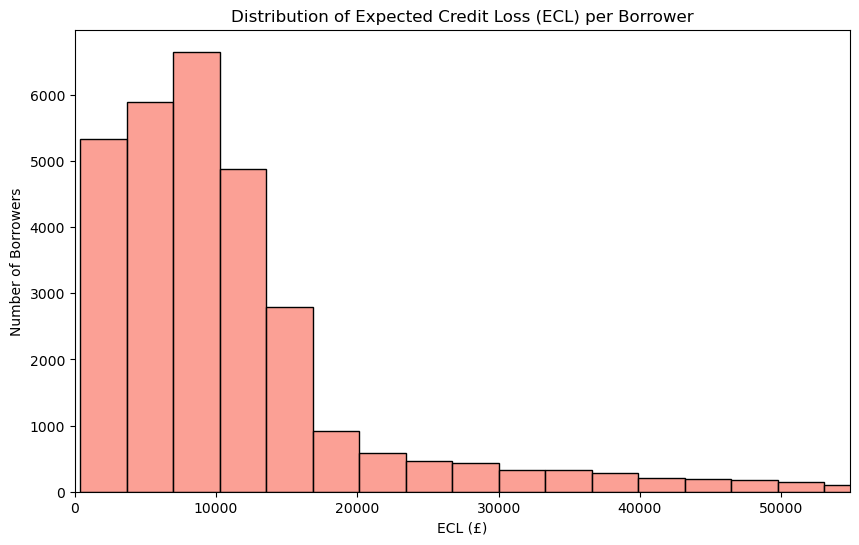

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(df['ECL'], bins=50, kde=False, color='salmon')
plt.title("Distribution of Expected Credit Loss (ECL) per Borrower")
plt.xlabel("ECL (£)")
plt.ylabel("Number of Borrowers")
plt.xlim(0, df['ECL'].quantile(0.99))  # zoom in to 99th percentile for clarity
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4132\3055393925.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=flag, y='default', data=df, ci=None)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4132\3055393925.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=flag, y='default', data=df, ci=None)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4132\3055393925.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=flag, y='default', data=df, ci=None)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4132\3055393925.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=flag, y='default', data=df, ci=None)


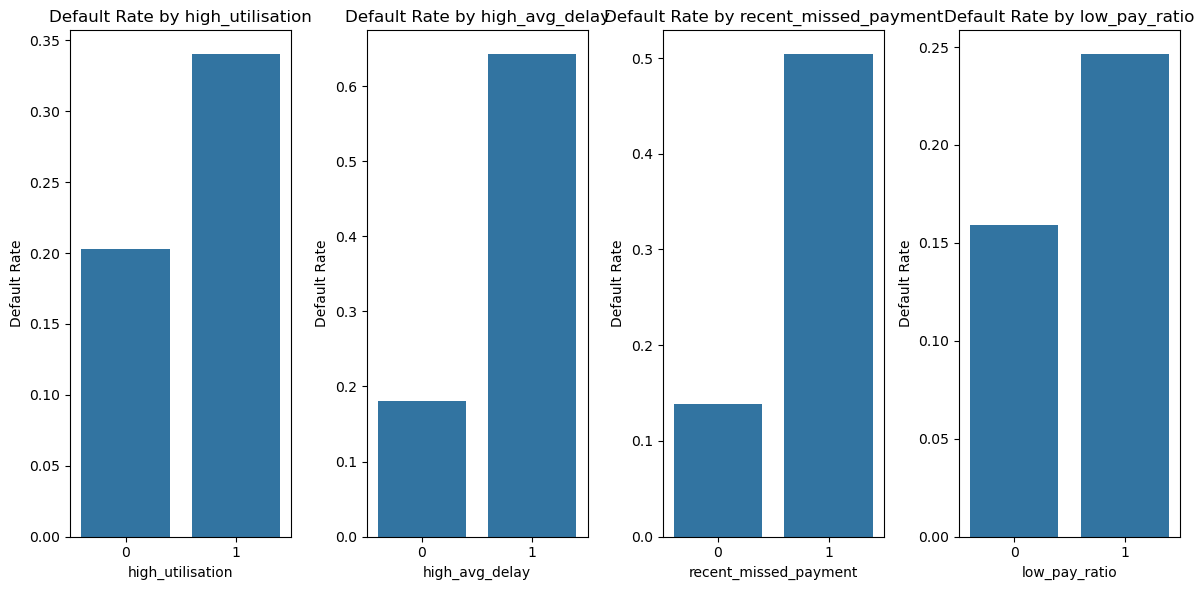

In [25]:
# Set up a figure
plt.figure(figsize=(12,6))

# Flags to visualize
flags = ['high_utilisation','high_avg_delay','recent_missed_payment','low_pay_ratio']

# Loop through each flag and plot
for i, flag in enumerate(flags, 1):
    plt.subplot(1, 4, i)
    sns.barplot(x=flag, y='default', data=df, ci=None)
    plt.title(f"Default Rate by {flag}")
    plt.ylabel("Default Rate")
    plt.xlabel(flag)

plt.tight_layout()
plt.show()

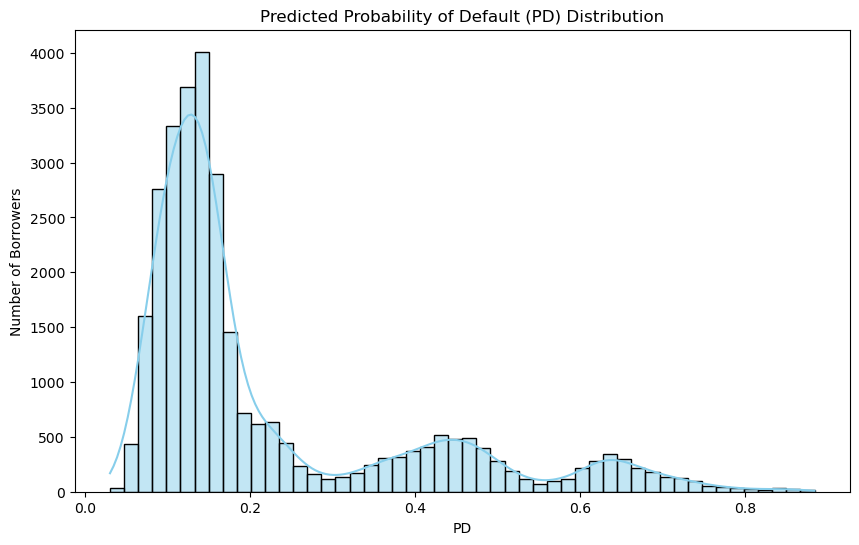

In [26]:
plt.figure(figsize=(10,6))
sns.histplot(df['PD'], bins=50, kde=True, color='skyblue')
plt.title("Predicted Probability of Default (PD) Distribution")
plt.xlabel("PD")
plt.ylabel("Number of Borrowers")
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4132\3848094696.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_ecl.index.astype(str), y='ECL', data=top_ecl, palette='Reds_r')


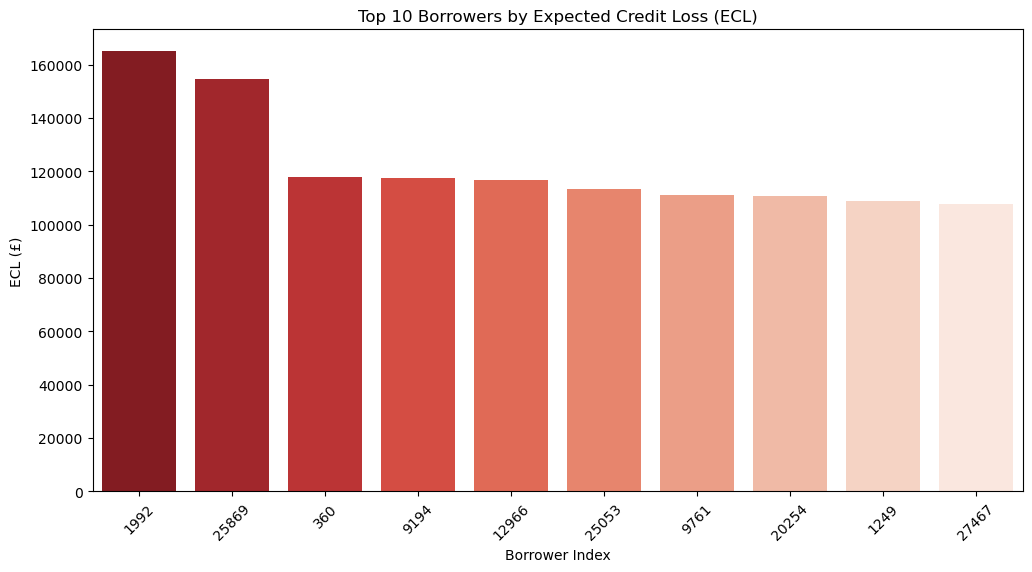

In [28]:
top_ecl = df[['LIMIT_BAL','PD','ECL']].sort_values(by='ECL', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_ecl.index.astype(str), y='ECL', data=top_ecl, palette='Reds_r')
plt.title("Top 10 Borrowers by Expected Credit Loss (ECL)")
plt.xlabel("Borrower Index")
plt.ylabel("ECL (£)")
plt.xticks(rotation=45)
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4132\1450366122.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df.pivot_table(index='delay_bin', columns='util_bin', values='PD', aggfunc='mean')


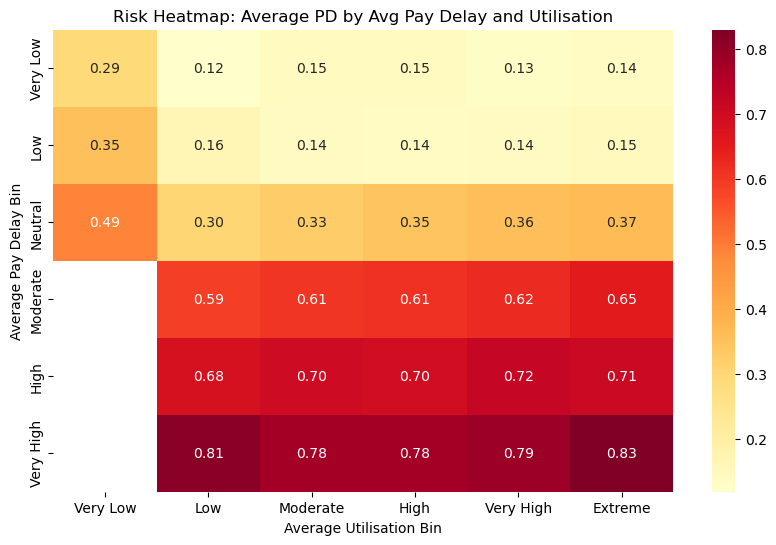

In [29]:
# Create bins for avg_pay_delay and utilisation_avg
df['delay_bin'] = pd.cut(df['avg_pay_delay'], bins=[-3,-1,0,1,2,3,6], labels=['Very Low','Low','Neutral','Moderate','High','Very High'])
df['util_bin'] = pd.cut(df['utilisation_avg'], bins=[-0.5,0,0.25,0.5,0.75,1,5], labels=['Very Low','Low','Moderate','High','Very High','Extreme'])

# Pivot table: mean PD per bin combination
heatmap_data = df.pivot_table(index='delay_bin', columns='util_bin', values='PD', aggfunc='mean')

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Risk Heatmap: Average PD by Avg Pay Delay and Utilisation")
plt.xlabel("Average Utilisation Bin")
plt.ylabel("Average Pay Delay Bin")
plt.show()